# Gibbs bot profile simulation analysis

This notebook reads the committed `evidence/simulated_data.zip` export directly and checks the simulated participant profile distribution, trial-level metadata, response validity, and a lightweight behavioral comparison. The results are simulation sanity checks only, not claims about human behavior.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 50
zip_path = Path("../simulated_data.zip").resolve()
assert zip_path.exists(), zip_path

with ZipFile(zip_path) as zf:
    with zf.open("regular/data/Bot.csv") as f:
        bots = pd.read_csv(f)
    with zf.open("regular/data/CustomTrial.csv") as f:
        trials = pd.read_csv(f)

bots = bots[bots["complete"] == True].copy()
trials = trials[trials["complete"] == True].copy()
trials["profile_metadata_json"] = trials["profile_metadata"].apply(json.loads)
metadata = pd.json_normalize(trials["profile_metadata_json"])
trials = pd.concat([trials.reset_index(drop=True), metadata.add_prefix("meta_")], axis=1)

print(f"Completed bots: {len(bots)}")
print(f"Completed color trials: {len(trials)}")
bots[["id", "bot_profile", "participant_group", "complete"]].sort_values("id")

Completed bots: 10
Completed color trials: 70


,id,bot_profile,participant_group,complete
0,1,normal_rgb,B,True
1,2,random,A,True
2,3,normal_rgb,B,True
3,4,normal_rgb,A,True
4,5,random,B,True
5,6,random,A,True
6,7,random,B,True
7,8,random,A,True
8,9,normal_rgb,B,True
9,10,normal_rgb,A,True


## Distribution and metadata checks

In [2]:
profile_counts = bots["bot_profile"].value_counts().sort_index()
group_counts = bots["participant_group"].value_counts().sort_index()
trial_profile_counts = trials.groupby("meta_bot_profile").size().sort_index()

assert len(bots) == 10
assert profile_counts.to_dict() == {"normal_rgb": 5, "random": 5}
assert group_counts.to_dict() == {"A": 5, "B": 5}
assert trial_profile_counts.to_dict() == {"normal_rgb": 35, "random": 35}
assert (trials["meta_participant_id"] == trials["participant_id"]).all()
assert (trials["meta_submitted_channel_response"] == trials["answer"]).all()
assert trials["answer"].between(0, 255).all()
assert (trials.groupby("participant_id")["meta_bot_profile"].nunique() == 1).all()

summary = pd.DataFrame({
    "completed_participants": profile_counts,
    "completed_color_trials": trial_profile_counts,
})
summary

,completed_participants,completed_color_trials
normal_rgb,5,35
random,5,35


The export contains exactly ten completed bots, a balanced 5/5 profile split, balanced A/B participant groups, and stable participant-level profiles across all color trials. Trial metadata links each response to profile, participant, target, active channel, starting RGB vector, and submitted channel response.

In [3]:
behavior = trials.groupby("meta_bot_profile").agg(
    response_min=("answer", "min"),
    response_max=("answer", "max"),
    response_sd=("answer", "std"),
    mean_abs_distance_from_start=("meta_response_distance_from_start", "mean"),
).round(2)
behavior

,response_min,response_max,response_sd,mean_abs_distance_from_start
meta_bot_profile,,,,
normal_rgb,0,255,78.19,21.34
random,0,248,74.19,90.17


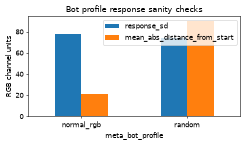

In [4]:
ax = behavior[["response_sd", "mean_abs_distance_from_start"]].plot(kind="bar", figsize=(5, 3), rot=0)
ax.set_title("Bot profile response sanity checks")
ax.set_ylabel("RGB channel units")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The `random` profile spans a wide response range, while `normal_rgb` responses stay closer to the displayed starting channel on average. This supports the intended profile distinction for local simulation evidence only.